# Figure 3A — E3 ligases acting on one another

Restricts the effect-size matrix to knockouts that are themselves measured as
response genes, so that a knockout's effect on another knockout's transcript
can be read directly. Draws the E3-on-E3 regulatory network and the
accompanying heatmaps.

Produces `figures/Figure_S3B.pdf` and `figures/Figure_S3XX.pdf`.

## Setup

In [1]:
library(pheatmap)
library(reshape2)
library(igraph)
library(repr)

save_pheatmap_pdf <- function(x, filename, width = 7, height = 7) {
    stopifnot(!missing(x), !missing(filename))
    pdf(filename, width = width, height = height)
    grid::grid.newpage()
    grid::grid.draw(x$gtable)
    dev.off()
}

dir.create("figures", showWarnings = FALSE)


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




In [2]:
E3LIGASE <- "/home/eraslab1/Projects/E3Ligase/analysisSingle"

BETA_ALL      <- file.path(E3LIGASE, "EffectSizes/MixedEffectLMOutputs/ME_LMBetaCoefsALL.csv")
FDR_ALL       <- file.path(E3LIGASE, "EffectSizes/MixedEffectLMOutputs/ME_LMBetaFDRALL.csv")
BETA_SIGNIF   <- file.path(E3LIGASE, "EffectSizes/MixedEffectLMOutputs/ME_SignificantBetaCoefs.csv")
GUIDE_MODULES <- file.path(E3LIGASE, "TextFiles/ME_GuideModules_leiden_6_Modules.csv")
E3_METADATA   <- file.path(E3LIGASE, "ManuscriptFigures/TextFiles/220610_regulators_metadata_E3_Complex.csv")

FDR_THRESHOLD <- 0.1     # effects less significant than this are set to zero
EFFECT_LIMIT  <- 0.2     # colour scale of the full effect map
NOT_A_KNOCKOUT <- c("Intercept", "n_genes", "mt_frac", "Group Var")

# module colours, shared by both annotated heatmaps
annoCols <- list(
    GeneGroup = c(G0 = "#A6CEE3", G1 = "#1F78B4", G2  = "#B2DF8A", G3 = "#33A02C",
                  G4 = "#FB9A99", G5 = "#FDBF6F", G6  = "#FF7F00", G7 = "#CAB2D6",
                  G8 = "#6A3D9A", G9 = "#FFFF99", G10 = "#B5651D"),
    GuideGroup = c(K0 = "#1f77b4", K1 = "#ff7f0e", K2 = "#279e68",
                   K3 = "#d62728", K4 = "#aa40fc", K5 = "#8c564b")
)

# module annotation for a set of knockouts, as pheatmap wants it
moduleAnnotation <- function(names) {
    annotation <- guideModules[names, ]
    annotation$GuideColor <- NULL
    annotation
}

## Effect sizes, with non-significant entries zeroed

Row names are guide identifiers; only the gene name part is kept. A handful of
knockouts are recorded under a synonym on the response side, so those columns
are duplicated under the guide's name.

In [3]:
coefsAll <- as.data.frame(read.csv(BETA_ALL, row.names = 1), stringsAsFactors = FALSE)
coefsAll <- coefsAll[!(rownames(coefsAll) %in% NOT_A_KNOCKOUT), ]

pValsAllAdj <- as.data.frame(read.csv(FDR_ALL, row.names = 1), stringsAsFactors = FALSE)

rownames(coefsAll)    <- sapply(rownames(coefsAll),    function(x) strsplit(as.character(x), "_")[[1]][2])
rownames(pValsAllAdj) <- sapply(rownames(pValsAllAdj), function(x) strsplit(as.character(x), "_")[[1]][2])
coefsAll[pValsAllAdj > FDR_THRESHOLD] <- 0

coefsAllSign <- as.data.frame(read.csv(BETA_SIGNIF, row.names = 1), stringsAsFactors = FALSE)
rownames(coefsAllSign) <- sapply(rownames(coefsAllSign), function(x) strsplit(as.character(x), "_")[[1]][2])
coefsAllSign[pValsAllAdj[rownames(coefsAllSign), colnames(coefsAllSign)] > FDR_THRESHOLD] <- 0

# gene symbol synonyms: guide name on the left, response gene name on the right
coefsAll$Rfwd2 <- coefsAll$Cop1
coefsAll$Tceb1 <- coefsAll$Eloc
coefsAll$Tceb3 <- coefsAll$Eloa
coefsAll$Vprbp <- coefsAll$Dcaf1
coefsAll$Tceb2 <- coefsAll$Elob

guideModules <- read.csv(GUIDE_MODULES, row.names = 1)
guideModules$GuideName  <- NULL
guideModules$GuideGroup <- factor(paste0("K", guideModules$GuideGroup))

## How many knockouts are also measured as response genes

In [4]:
koGuideNames    <- rownames(coefsAll)
sgnkoGuideNames <- rownames(coefsAllSign)
availKOs        <- koGuideNames[koGuideNames %in% colnames(coefsAll)]
availKOsSgn     <- sgnkoGuideNames[sgnkoGuideNames %in% colnames(coefsAll)]

cat("knockouts                       :", length(koGuideNames), "\n")
cat("  also measured as response gene:", length(availKOs), "\n")
cat("with a significant effect       :", length(sgnkoGuideNames), "\n")
cat("  also measured as response gene:", length(availKOsSgn), "\n")

knockouts                       : 1031 
  also measured as response gene: 544 
with a significant effect       : 329 
  also measured as response gene: 255 


## Annotated E3 ligases

The self-effect of each knockout on its own transcript is a sanity check: it
should be negative.

In [5]:
realE3s <- as.data.frame(read.csv(E3_METADATA), stringsAsFactors = FALSE)
e3s <- unique(realE3s$Symbol_guides)
e3s <- e3s[e3s != ""]
availE3s <- e3s[e3s %in% colnames(coefsAll)]

cat("annotated E3 ligases      :", length(e3s), "\n")
cat("  measurable as response  :", length(availE3s), "\n")
cat("  not measurable          :", paste(e3s[!(e3s %in% colnames(coefsAll))], collapse = ", "), "\n\n")

selfEffects <- diag(as.matrix(coefsAll[availKOs, availKOs]))
cat("non-zero self-effects     :", length(selfEffects[selfEffects != 0]), "\n")
cat("  of which negative       :", length(selfEffects[selfEffects < 0]), "\n")

annotated E3 ligases      : 165 
  measurable as response  : 136 
  not measurable          : E4f1, Brca1, Cblc, Ring1, Siah1a, Traf3ip2, Trim7, Wdhd1, Rnf113a1, Rnf135, Trim24, Rnf144a, Hectd3, Trim45, Kbtbd13, Klhl3, Katnb1, Lrr1, Ccnf, Fbxo42, Bid, Klhl7, Dcaf4, Fbxl13, Grb10, Kctd13, Kctd21, Det1, Bcl6 

non-zero self-effects     : 139 
  of which negative       : 135 


## The full knockout-by-knockout effect map

Every knockout that is also a response gene, against every other. Values are
clipped so a few strong effects do not flatten the colour scale.

This panel is displayed but not written to file, as in the original notebook.

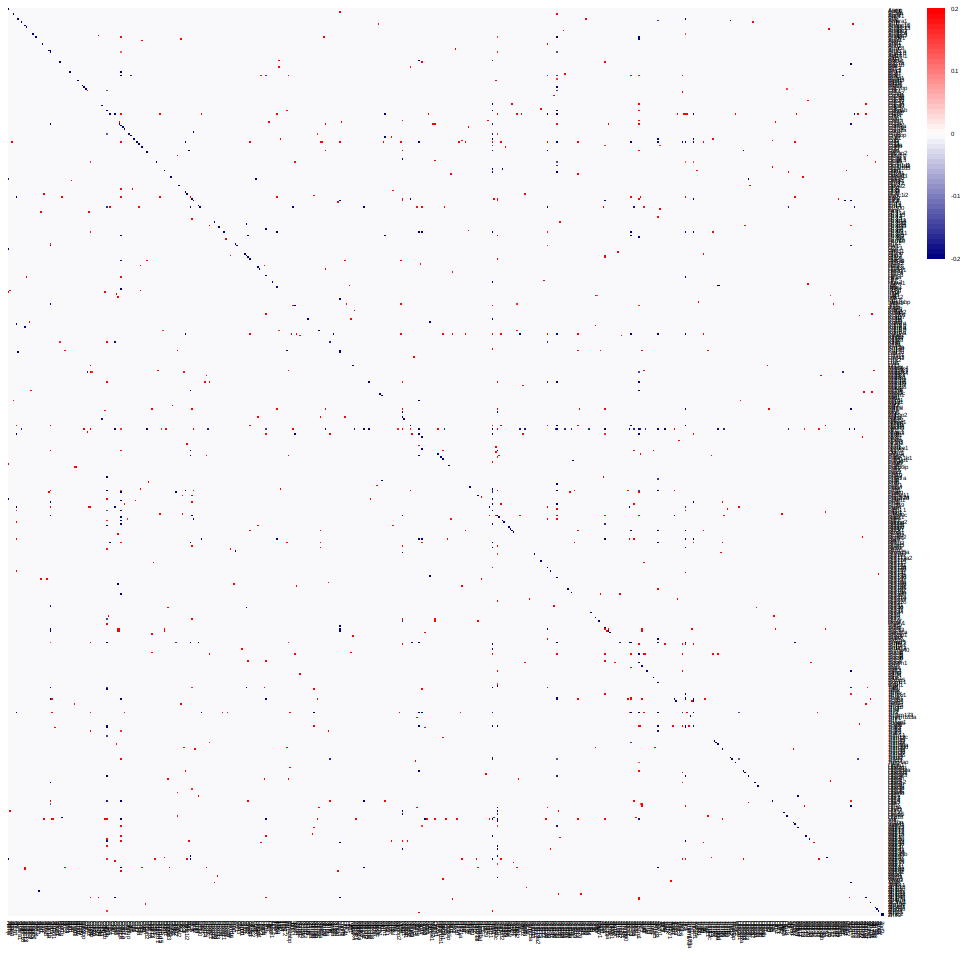

In [6]:
options(repr.plot.width = 8, repr.plot.height = 8)

koEffectMap <- coefsAll[availKOs, availKOs]
koEffectMap[koEffectMap >  EFFECT_LIMIT] <-  EFFECT_LIMIT
koEffectMap[koEffectMap < -EFFECT_LIMIT] <- -EFFECT_LIMIT

pheatmap(
    koEffectMap, treeheight_col = 0, treeheight_row = 0, fontsize = 3,
    cluster_rows = FALSE, cluster_cols = FALSE,
    color = colorRampPalette(c("navy", "white", "red"))(50)
)

## E3 ligases acting on other E3 ligases — Supp. 3B

Self-effects are removed so only cross-regulation remains, and rows and
columns with no remaining effect are dropped. What is left is reduced to the
sign of each effect.

In [7]:
e3Effects <- coefsAll[e3s, availE3s]

# drop self-effects: a knockout's effect on its own transcript is not regulation
for (gene in intersect(rownames(e3Effects), colnames(e3Effects))) {
    e3Effects[gene, gene] <- 0
}

# keep only E3s that act, and E3s that are acted upon
actingE3s   <- apply(e3Effects, 1, function(x) sum(x != 0)) > 0
e3Effects   <- e3Effects[actingE3s, ]
affectedE3s <- apply(e3Effects, 2, function(x) sum(x != 0)) > 0
e3Effects   <- e3Effects[, affectedE3s]

e3Effects[e3Effects > 0] <-  1
e3Effects[e3Effects < 0] <- -1

dim(e3Effects)

[1] 60 37

agg_record_1071332617 
                    2

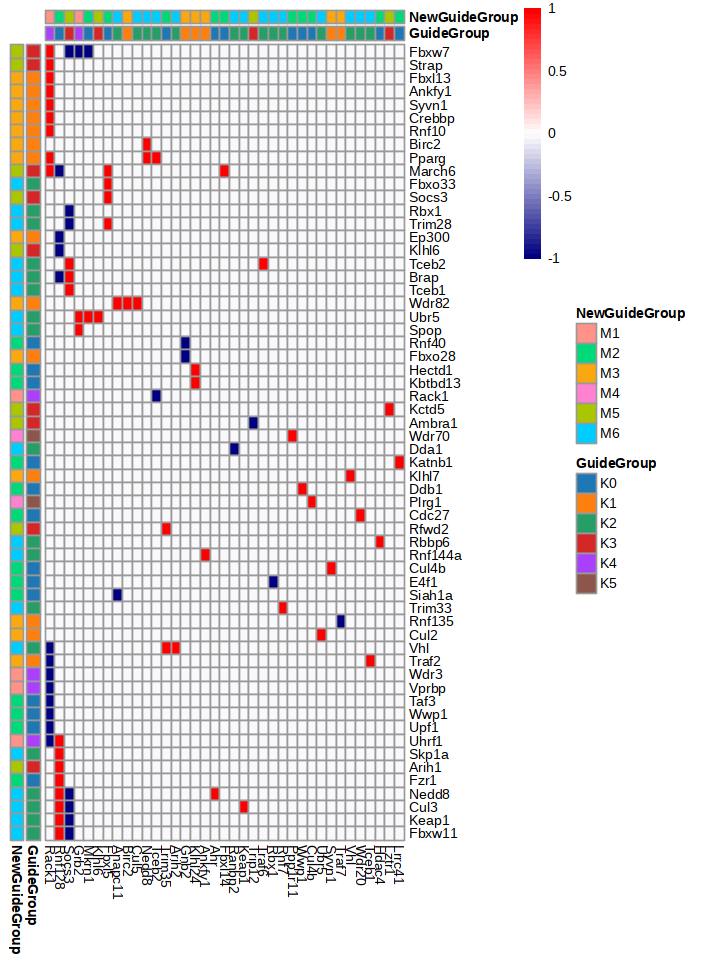

In [8]:
options(repr.plot.width = 6, repr.plot.height = 8)

xx <- pheatmap(
    e3Effects, treeheight_col = 0, treeheight_row = 0, fontsize = 8,
    clustering_method = "ward.D2", cluster_rows = TRUE, cluster_cols = TRUE,
    annotation_col = moduleAnnotation(colnames(e3Effects)),
    annotation_row = moduleAnnotation(rownames(e3Effects)),
    annotation_colors = annoCols,
    color = colorRampPalette(c("navy", "white", "red"))(50)
)
save_pheatmap_pdf(xx, "figures/Figure_S4A.pdf", width = 7, height = 8)

## The regulatory network — Figure 3A

Each surviving effect becomes a directed edge, coloured by whether the
knockout raises or lowers the target.

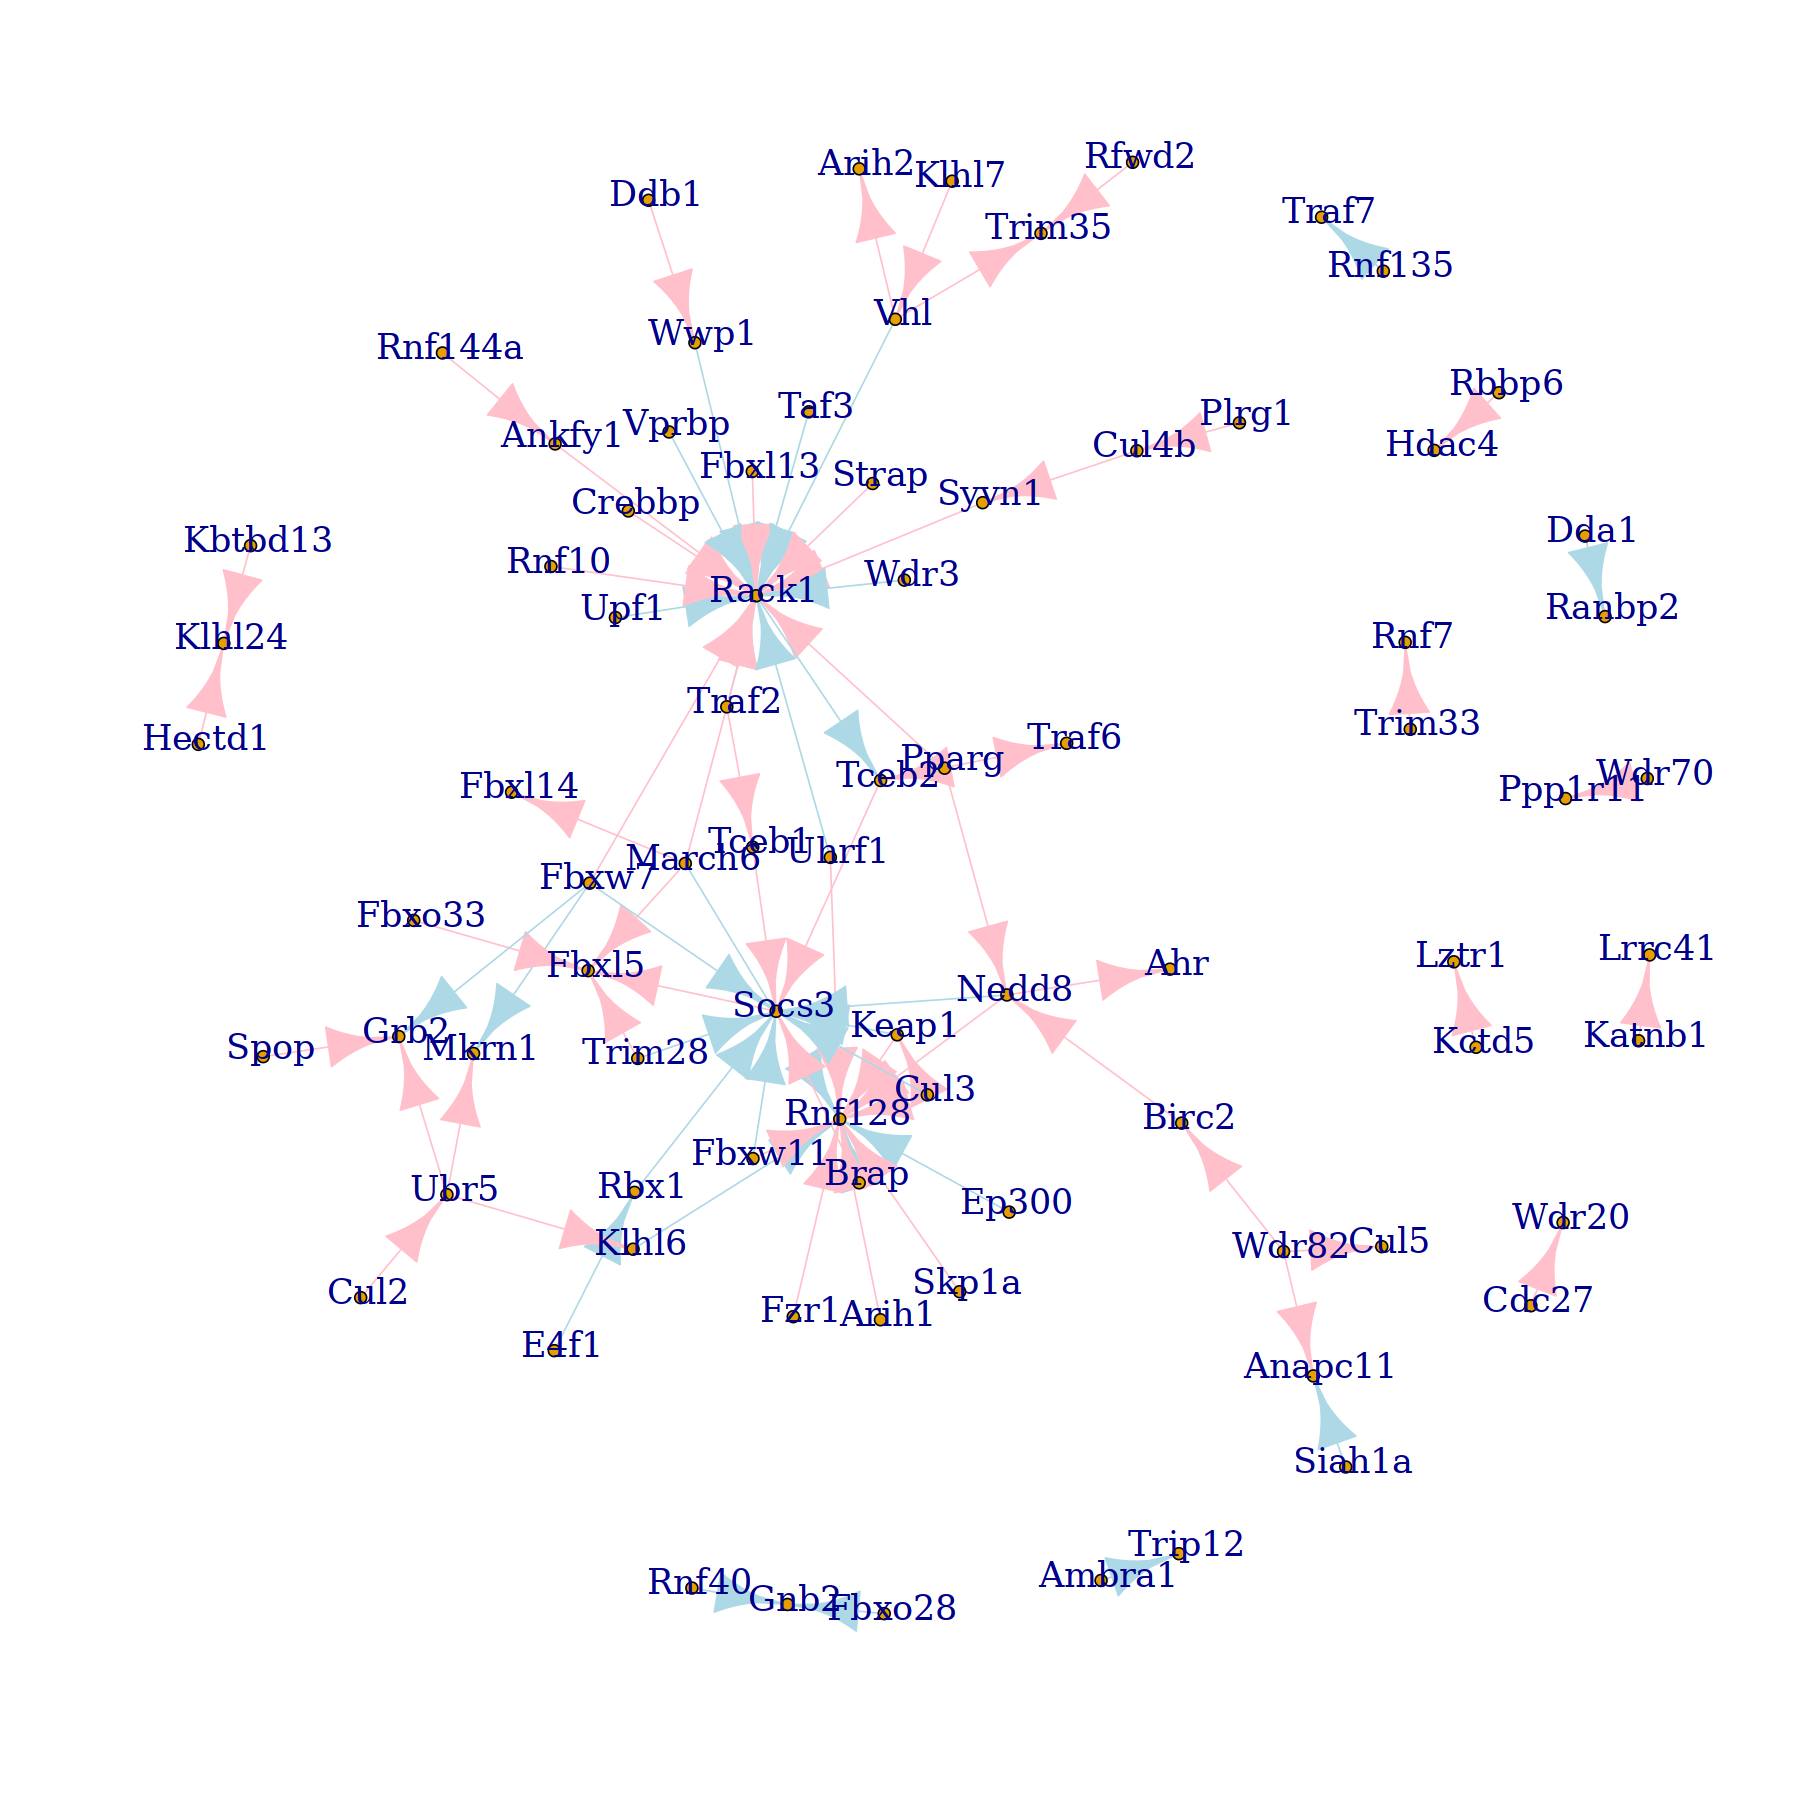

In [9]:
e3Effects$KOGene <- rownames(e3Effects)
edges <- melt(e3Effects, id.vars = "KOGene")
edges <- edges[edges$value != 0, ]
colnames(edges) <- c("KOGene", "AffectedGene", "Value")

set.seed(123)
options(repr.plot.width = 15, repr.plot.height = 15)

networkGraph <- graph_from_data_frame(d = edges, directed = TRUE)
V(networkGraph)$label.cex <- 1.7
E(networkGraph)$sign  <- ifelse(edges$Value > 0, 1, -1)
E(networkGraph)$color <- ifelse(E(networkGraph)$sign > 0, "pink", "lightblue")

plot(
    networkGraph, vertex.label = V(networkGraph)$name,
    vertex.size = 1.5, vertex.label.dist = 0.2,
    layout = layout_(networkGraph, nicely())
)

## The same effects ordered by guide module — Supp. 3XX

agg_record_1320857092 
                    2

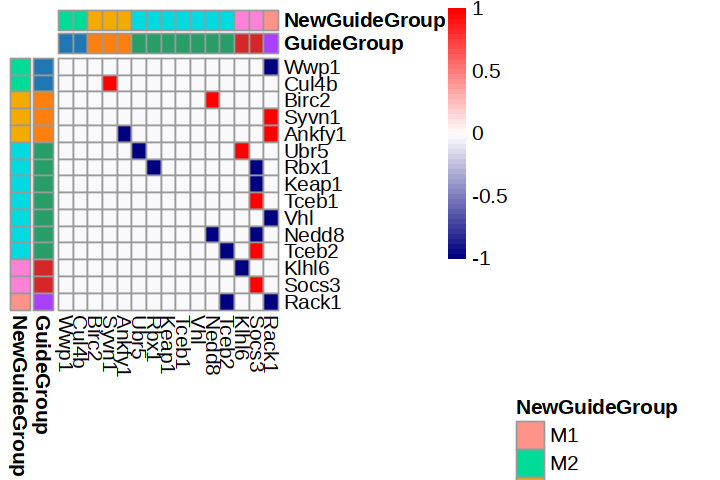

In [10]:
options(repr.plot.width = 6, repr.plot.height = 4)

reciprocalE3s <- intersect(colnames(e3Effects), rownames(e3Effects))
ordered <- guideModules[reciprocalE3s, ]
reciprocalE3s <- rownames(ordered[order(ordered$GuideGroup), ])

onlyE3s <- coefsAll[reciprocalE3s, reciprocalE3s]
onlyE3s[onlyE3s > 0] <-  1
onlyE3s[onlyE3s < 0] <- -1

xx <- pheatmap(
    onlyE3s, treeheight_col = 0, treeheight_row = 0, fontsize = 12,
    clustering_method = "ward.D2", cluster_rows = FALSE, cluster_cols = FALSE,
    annotation_col = moduleAnnotation(colnames(onlyE3s)),
    annotation_row = moduleAnnotation(rownames(onlyE3s)),
    annotation_colors = annoCols,
    color = colorRampPalette(c("navy", "white", "red"))(50)
)
save_pheatmap_pdf(xx, "figures/Figure_S4B.pdf", width = 6, height = 4)

## Network modularity

In [11]:
communities <- cluster_edge_betweenness(networkGraph)
modularity(communities)

[1] 0.3658131